# Real-Time Speech Emotion Recognition for Context-Aware LLMs
### ALL 3 Datasets: RAVDESS + CREMA-D + IEMOCAP | Optimized for RTX 3050 Ti (4GB)

---
## Your Hardware Profile
| Component | Spec | Impact |
|-----------|------|--------|
| GPU | RTX 3050 Ti Laptop, **4 GB VRAM** | Tight — HuBERT batch=2, mixed precision ON |
| RAM | 16 GB DDR4 | OK for all 3 datasets combined |
| CPU | i5-12450H, 12 threads | `num_workers=0` (Windows safe) |

## Expected Folder Structure
```
data/
├── ravdess/
│   ├── Actor_01/03-01-01-01-01-01-01.wav
│   └── Actor_24/...
├── crema-d/
│   └── AudioWAV/1001_DFA_ANG_XX.wav
└── iemocap/
    ├── Session1/
    │   ├── sentences/wav/Ses01F_impro01/Ses01F_impro01_F000.wav
    │   └── dialog/EmoEvaluation/Ses01F_impro01.txt
    ├── Session2/ ... Session5/
```

## Unified 6-Class Emotion Mapping
| Class | RAVDESS | CREMA-D | IEMOCAP |
|-------|---------|---------|--------|
| neutral  | 01, **02(calm→neu)** | NEU | neu |
| happy    | 03 | HAP | hap + **exc** |
| sad      | 04 | SAD | sad |
| angry    | 05 | ANG | ang + **fru** |
| fearful  | 06 | FEA | fea |
| disgust  | 07 | DIS | dis |
| dropped  | 08(surprised) | — | sur, xxx |

In [1]:
# ============================================================
# CELL 1 — Install dependencies
# RTX 3050 Ti / Windows safe — no risky system changes
# ============================================================
import subprocess, sys

def pip(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])

pip(
    'torch', 'torchaudio',
    'transformers', 'accelerate',
    'openai-whisper', 'openai',
    'scikit-learn', 'seaborn',
    'tqdm', 'pandas', 'matplotlib'
)

# sounddevice for real-time mic (optional — skip if no mic)
try:
    pip('sounddevice')
except Exception:
    print('sounddevice install failed — real-time mic cell will be skipped')

print('All packages installed.')

All packages installed.


In [2]:
# ============================================================
# CELL 2 — Imports & Global Config
# Config kept from your adjustments — optimized for 3050 Ti
# ============================================================
import os, re, random, json, time, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import torchaudio.transforms as T
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR

from sklearn.metrics import (
    accuracy_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.preprocessing import LabelEncoder
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

# ---- YOUR CONFIG (kept exactly as you set it) ----
CFG = {
    'seed'        : 42,
    'sr'          : 16_000,
    'clip_sec'    : 2.0,        # your setting — good for 4GB VRAM
    'n_mfcc'      : 40,
    'n_mels'      : 128,
    'n_fft'       : 512,
    'hop_length'  : 160,
    'win_length'  : 400,
    'f_min'       : 80,
    'f_max'       : 7600,
    'batch_size'  : 8,          # your setting — safe for CNN/LSTM on 4GB
    'epochs'      : 30,         # your setting
    'lr'          : 1e-4,
    'dropout'     : 0.3,
    'num_workers' : 0,          # your setting — MUST be 0 on Windows
    'device'      : 'cuda' if torch.cuda.is_available() else 'cpu',
    'num_classes' : 6,
}

# HuBERT needs smaller batch to fit in 4GB VRAM
# Mixed precision + gradient checkpointing also enabled below
HUBERT_CFG = {
    **CFG,
    'lr'         : 1e-5,   # lower LR prevents catastrophic forgetting
    'batch_size' : 2,      # your setting — correct for 4GB with HuBERT-base
    'epochs'     : 30,
    'num_workers': 0,      # keep 0 on Windows
}

random.seed(CFG['seed'])
np.random.seed(CFG['seed'])
torch.manual_seed(CFG['seed'])
if CFG['device'] == 'cuda':
    torch.cuda.manual_seed_all(CFG['seed'])
    # Deterministic ops (slight slowdown but reproducible)
    torch.backends.cudnn.benchmark = True  # faster conv for fixed input size

print(f"Device    : {CFG['device']}")
if CFG['device'] == 'cuda':
    print(f"GPU       : {torch.cuda.get_device_name(0)}")
    total_vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"VRAM      : {total_vram:.1f} GB")
print(f"PyTorch   : {torch.__version__}")
print(f"torchaudio: {torchaudio.__version__}")

KeyboardInterrupt: 

Parsing RAVDESS...
  RAVDESS: 1248 samples, 24 speakers
Parsing CREMA-D...
  CREMA-D: 7442 samples, 91 speakers
Parsing IEMOCAP...
IEMOCAP: 0 utterances from 0 speakers

====== COMBINED DATASET ======
Total samples : 8690
Total speakers: 115

Per dataset:
dataset
cremad     7442
ravdess    1248

Per emotion:
label
happy      1463
sad        1463
angry      1463
fearful    1463
disgust    1463
neutral    1375


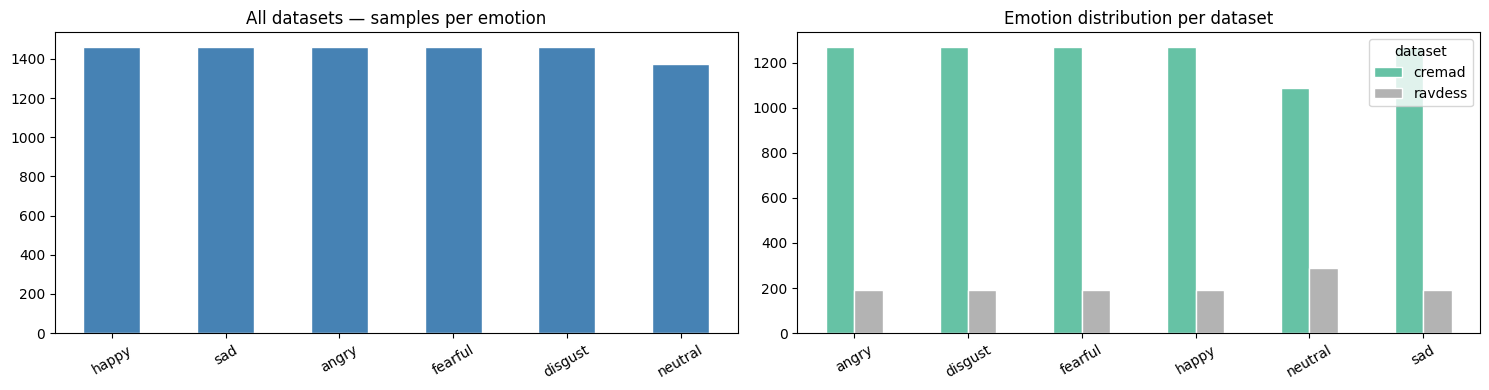

Plot saved as dataset_distribution.png


In [ ]:
# ============================================================
# CELL 3 — Parse ALL 3 Datasets
# RAVDESS + CREMA-D + IEMOCAP → unified 6-class label set
# ============================================================

UNIFIED_EMOTIONS = ['neutral', 'happy', 'sad', 'angry', 'fearful', 'disgust']

# ---------- RAVDESS ----------
# Filename: 03-01-EM-IN-ST-RP-AC.wav
RAVDESS_MAP = {
    '01': 'neutral',
    '02': 'neutral',   # calm → neutral (same low-arousal class)
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': None,        # surprised — no equivalent, dropped
}

def parse_ravdess(root='data/ravdess'):
    records = []
    for wav in Path(root).rglob('*.wav'):
        parts = wav.stem.split('-')
        if len(parts) != 7:
            continue
        label    = RAVDESS_MAP.get(parts[2])
        actor_id = int(parts[6])
        if label:
            records.append({
                'path'      : str(wav),
                'label'     : label,
                'speaker_id': f'R{actor_id:03d}',
                'dataset'   : 'ravdess'
            })
    return pd.DataFrame(records)


# ---------- CREMA-D ----------
# Filename: ActorID_Sentence_EMOTION_Level.wav
CREMAD_MAP = {
    'ANG': 'angry',
    'DIS': 'disgust',
    'FEA': 'fearful',
    'HAP': 'happy',
    'NEU': 'neutral',
    'SAD': 'sad',
}

def parse_cremad(audio_dir='data/crema-d/AudioWAV'):
    records = []
    for wav in Path(audio_dir).glob('*.wav'):
        parts = wav.stem.split('_')
        if len(parts) < 3:
            continue
        label = CREMAD_MAP.get(parts[2])
        if label:
            records.append({
                'path'      : str(wav),
                'label'     : label,
                'speaker_id': f'C{parts[0]}',
                'dataset'   : 'cremad'
            })
    return pd.DataFrame(records)


# ---------- IEMOCAP ----------
# Sessions 1-5, each has:
#   sentences/wav/{dialog_id}/{utt_id}.wav
#   dialog/EmoEvaluation/{dialog_id}.txt
#
# EmoEvaluation line format:
#   [start - end]  Ses01F_impro01_F000  neu  [2.5000, 2.5000, 2.5000]
#
IEMOCAP_MAP = {
    'neu': 'neutral',
    'hap': 'happy',
    'exc': 'happy',    # excited → happy (same high-arousal positive)
    'sad': 'sad',
    'ang': 'angry',
    'fru': 'angry',    # frustrated → angry (high-arousal negative)
    'fea': 'fearful',
    'dis': 'disgust',
    'sur': None,       # surprised — dropped (no RAVDESS/CREMA-D equivalent)
    'xxx': None,       # ambiguous — dropped
    'oth': None,       # other — dropped
}

def parse_iemocap(root='data/iemocap'):
    """
    Parses all 5 IEMOCAP sessions.
    Each session has 2 speakers: Male (M) and Female (F).
    Speaker ID format: I{session}{gender} e.g. I1M, I1F, I2M ...
    """
    records = []
    root_p  = Path(root)

    for session_dir in sorted(root_p.glob('Session*')):
        session_num = session_dir.name.replace('Session', '')
        eval_dir    = session_dir / 'dialog' / 'EmoEvaluation'
        wav_base    = session_dir / 'sentences' / 'wav'

        if not eval_dir.exists():
            print(f'  WARNING: {eval_dir} not found, skipping session {session_num}')
            continue

        for eval_file in eval_dir.glob('*.txt'):
            dialog_id = eval_file.stem   # e.g. Ses01F_impro01

            try:
                lines = eval_file.read_text(encoding='utf-8', errors='ignore').splitlines()
            except Exception as e:
                print(f'  Could not read {eval_file}: {e}')
                continue

            for line in lines:
                line = line.strip()
                # Only process utterance lines (start with '[')
                if not line.startswith('['):
                    continue
                parts = line.split()
                # Format: [start - end]  utt_id  emotion  [val, act, dom]
                # parts:   0      1  2   3        4        5+
                if len(parts) < 5:
                    continue

                utt_id  = parts[3]   # e.g. Ses01F_impro01_F000
                em_code = parts[4].lower()
                label   = IEMOCAP_MAP.get(em_code)

                if not label:
                    continue  # skip sur/xxx/oth

                # Determine speaker gender from utterance ID suffix
                # Ses01F_impro01_F000 → F = Female, M = Male
                gender = 'F' if '_F' in utt_id.split('_')[-1] else 'M'
                speaker_id = f'I{session_num}{gender}'

                # Construct wav path
                wav_path = wav_base / dialog_id / f'{utt_id}.wav'
                if not wav_path.exists():
                    # Some sessions use .WAV uppercase
                    wav_path = wav_base / dialog_id / f'{utt_id}.WAV'
                if not wav_path.exists():
                    continue

                records.append({
                    'path'      : str(wav_path),
                    'label'     : label,
                    'speaker_id': speaker_id,
                    'dataset'   : 'iemocap'
                })

    df = pd.DataFrame(records)
    print(f'IEMOCAP: {len(df)} utterances from '
          f'{df["speaker_id"].nunique() if len(df) else 0} speakers')
    return df


# ---- Parse all 3 ----
print('Parsing RAVDESS...')
df_rav = parse_ravdess('data/ravdess')
print(f'  RAVDESS: {len(df_rav)} samples, {df_rav["speaker_id"].nunique()} speakers')

print('Parsing CREMA-D...')
df_cre = parse_cremad('data/crema-d/AudioWAV')
print(f'  CREMA-D: {len(df_cre)} samples, {df_cre["speaker_id"].nunique()} speakers')

print('Parsing IEMOCAP...')
df_iem = parse_iemocap('data/iemocap')

# ---- Combine ----
df_all = pd.concat([df_rav, df_cre, df_iem], ignore_index=True)

le = LabelEncoder().fit(UNIFIED_EMOTIONS)
df_all['label_id'] = le.transform(df_all['label'])

print(f'\n====== COMBINED DATASET ======')
print(f'Total samples : {len(df_all)}')
print(f'Total speakers: {df_all["speaker_id"].nunique()}')
print(f'\nPer dataset:')
print(df_all['dataset'].value_counts().to_string())
print(f'\nPer emotion:')
print(df_all['label'].value_counts().to_string())

# ---- Plot ----
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Overall distribution
df_all['label'].value_counts().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('All datasets — samples per emotion')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

# Per-dataset breakdown
pivot = df_all.groupby(['label', 'dataset']).size().unstack(fill_value=0)
pivot.plot(kind='bar', ax=axes[1], colormap='Set2', edgecolor='white')
axes[1].set_title('Emotion distribution per dataset')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('dataset_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print('Plot saved as dataset_distribution.png')

In [ ]:
# ============================================================
# CELL 4 — Speaker-Independent Train / Val / Test Split
# Split by speaker ID NOT by sample — prevents identity leakage
# ============================================================

def speaker_independent_split(df, val_ratio=0.15, test_ratio=0.15, seed=42):
    """
    WHY THIS MATTERS:
    If you split by sample, the same speaker appears in train AND test.
    The model learns voice timbre instead of emotion → inflated accuracy +10-15%.
    Speaker-independent split = real-world generalization.

    IEMOCAP has 10 speakers (5 sessions × 2 genders).
    RAVDESS has 24.  CREMA-D has 91.  Total: ~125 unique speakers.
    """
    speakers = df['speaker_id'].unique().tolist()
    random.seed(seed)
    random.shuffle(speakers)

    n      = len(speakers)
    n_test = int(n * test_ratio)
    n_val  = int(n * val_ratio)

    test_spk  = set(speakers[:n_test])
    val_spk   = set(speakers[n_test : n_test + n_val])
    train_spk = set(speakers[n_test + n_val:])

    df_train = df[df['speaker_id'].isin(train_spk)].reset_index(drop=True)
    df_val   = df[df['speaker_id'].isin(val_spk)].reset_index(drop=True)
    df_test  = df[df['speaker_id'].isin(test_spk)].reset_index(drop=True)
    return df_train, df_val, df_test


df_train, df_val, df_test = speaker_independent_split(df_all)

print(f'Train: {len(df_train):,} samples | {df_train["speaker_id"].nunique()} speakers')
print(f'Val  : {len(df_val):,} samples | {df_val["speaker_id"].nunique()} speakers')
print(f'Test : {len(df_test):,} samples | {df_test["speaker_id"].nunique()} speakers')

# Verify zero leakage
assert not (set(df_train['speaker_id']) & set(df_test['speaker_id'])), 'TRAIN/TEST LEAKAGE!'
assert not (set(df_train['speaker_id']) & set(df_val['speaker_id'])),  'TRAIN/VAL LEAKAGE!'
assert not (set(df_val['speaker_id'])   & set(df_test['speaker_id'])), 'VAL/TEST LEAKAGE!'
print('No speaker leakage confirmed.')

# Check dataset coverage across splits
for split_name, split_df in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    coverage = split_df['dataset'].value_counts().to_dict()
    print(f'{split_name}: {coverage}')

Train: 6,088 samples | 81 speakers
Val  : 1,268 samples | 17 speakers
Test : 1,334 samples | 17 speakers
No speaker leakage confirmed.
Train: {'cremad': 5152, 'ravdess': 936}
Val: {'cremad': 1060, 'ravdess': 208}
Test: {'cremad': 1230, 'ravdess': 104}


RAVDESS   : mfcc=torch.Size([1, 120, 201]) | lmel=torch.Size([1, 128, 201]) | wav=torch.Size([1, 32000])
CREMA-D   : mfcc=torch.Size([1, 120, 201]) | lmel=torch.Size([1, 128, 201]) | wav=torch.Size([1, 32000])
IEMOCAP: EMPTY — check path


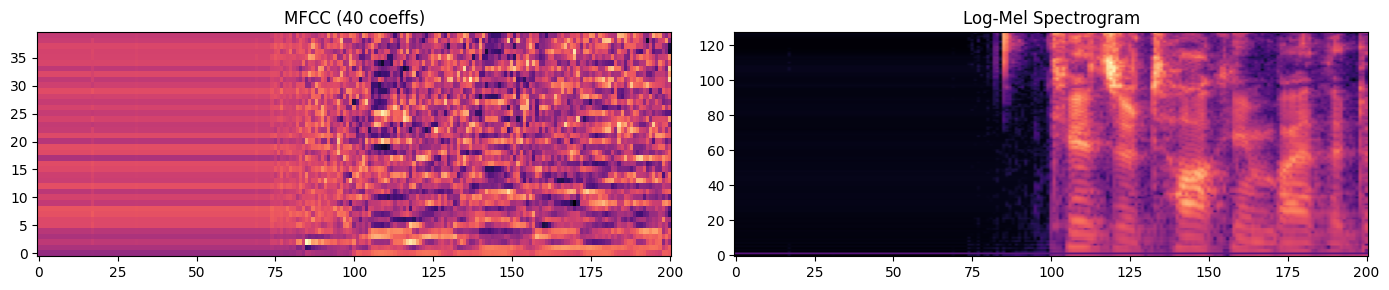

In [ ]:
# ============================================================
# CELL 5 — Audio Preprocessor
# clip_sec=2.0 kept (your setting) — saves ~25% VRAM vs 3s
# ============================================================

class AudioPreprocessor:
    """
    Pipeline per audio file:
      load → resample to 16kHz → mono → pad/trim to clip_sec
      → MFCC + delta + delta-delta  [1, 120, T]
      → Log-Mel Spectrogram         [1, 128, T]
      → peak-norm waveform          [1, T_samples]  (for HuBERT)

    clip_sec=2.0 @ 16kHz = 32000 samples
    T_frames = 32000 / 160 = 200 frames
    """

    def __init__(self, cfg=CFG):
        self.sr        = cfg['sr']
        self.n_samples = int(cfg['sr'] * cfg['clip_sec'])  # 32000

        self.mfcc_tfm = T.MFCC(
            sample_rate=cfg['sr'],
            n_mfcc=cfg['n_mfcc'],
            melkwargs={
                'n_fft'      : cfg['n_fft'],
                'hop_length' : cfg['hop_length'],
                'win_length' : cfg['win_length'],
                'n_mels'     : cfg['n_mels'],
                'f_min'      : cfg['f_min'],
                'f_max'      : cfg['f_max'],
            }
        )
        self.mel_tfm = T.MelSpectrogram(
            sample_rate=cfg['sr'],
            n_fft=cfg['n_fft'],
            hop_length=cfg['hop_length'],
            win_length=cfg['win_length'],
            n_mels=cfg['n_mels'],
            f_min=cfg['f_min'],
            f_max=cfg['f_max']
        )
        self.amp_to_db = T.AmplitudeToDB(top_db=80)
        self.delta     = T.ComputeDeltas()

    def load(self, path):
        wav, sr = torchaudio.load(str(path))
        if wav.shape[0] > 1:                    # stereo → mono
            wav = wav.mean(0, keepdim=True)
        if sr != self.sr:
            wav = T.Resample(sr, self.sr)(wav)
        return wav

    def pad_or_trim(self, wav):
        n = wav.shape[-1]
        if n >= self.n_samples:
            return wav[..., :self.n_samples]
        pad = self.n_samples - n
        # 50/50 front+back pad keeps speech centred
        return F.pad(wav, (pad // 2, pad - pad // 2))

    @staticmethod
    def normalize(t):
        mean = t.mean(dim=-1, keepdim=True)
        std  = t.std(dim=-1, keepdim=True).clamp(min=1e-6)
        return (t - mean) / std

    def __call__(self, path):
        wav  = self.load(path)
        wav  = self.pad_or_trim(wav)

        mfcc   = self.mfcc_tfm(wav)
        d1     = self.delta(mfcc)
        d2     = self.delta(d1)
        mfcc_f = torch.cat([mfcc, d1, d2], dim=1)   # [1, 120, 200]

        mel    = self.mel_tfm(wav)
        lmel   = self.amp_to_db(mel)                 # [1, 128, 200]

        wav_norm = wav / wav.abs().max().clamp(min=1e-6)

        return self.normalize(mfcc_f), self.normalize(lmel), wav_norm


preprocessor = AudioPreprocessor(CFG)

# Sanity check on one sample from each dataset
for ds_name, ds_df in [('RAVDESS', df_rav), ('CREMA-D', df_cre), ('IEMOCAP', df_iem)]:
    if len(ds_df) == 0:
        print(f'{ds_name}: EMPTY — check path')
        continue
    p = ds_df['path'].iloc[0]
    mfcc, lmel, wav = preprocessor(p)
    print(f'{ds_name:10s}: mfcc={mfcc.shape} | lmel={lmel.shape} | wav={wav.shape}')

# Visualise one sample
sample_path = df_train['path'].iloc[0]
mfcc, lmel, wav = preprocessor(sample_path)
fig, axes = plt.subplots(1, 2, figsize=(14, 3))
axes[0].imshow(mfcc[0, :40].numpy(), aspect='auto', origin='lower', cmap='magma')
axes[0].set_title('MFCC (40 coeffs)')
axes[1].imshow(lmel[0].numpy(), aspect='auto', origin='lower', cmap='magma')
axes[1].set_title('Log-Mel Spectrogram')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 6 — Data Augmentation
# pitch_shift commented out (slow on CPU — your choice to enable)
# ============================================================

class SpeechAugment:
    """All ops on waveform [1, T] and/or spectrogram [C, F, T]."""

    def __init__(self, sr=16_000, p=0.5):
        self.sr = sr
        self.p  = p

    def add_gaussian_noise(self, wav, snr_db_range=(10, 30)):
        snr       = random.uniform(*snr_db_range)
        sig_pow   = wav.norm(p=2) ** 2 / wav.numel()
        noise_pow = sig_pow / (10 ** (snr / 10))
        return (wav + torch.randn_like(wav) * noise_pow.sqrt()).clamp(-1.0, 1.0)

    def add_pink_noise(self, wav, noise_level=(0.002, 0.015)):
        """Pink (1/f) noise simulates room acoustics better than white noise."""
        f     = torch.fft.rfftfreq(wav.shape[-1]).clamp(min=1e-6)
        pink  = (1.0 / f.sqrt()) * torch.randn(len(f), dtype=torch.complex64)
        noise = torch.fft.irfft(pink, n=wav.shape[-1]).unsqueeze(0)
        noise = noise / noise.abs().max().clamp(min=1e-6)
        alpha = random.uniform(*noise_level)
        return (wav + alpha * noise).clamp(-1.0, 1.0)

    def volume_perturb(self, wav, db_range=(-6, 6)):
        db = random.uniform(*db_range)
        return (wav * (10 ** (db / 20))).clamp(-1.0, 1.0)

    # NOTE: pitch_shift is slow without GPU acceleration
    # Enable only if you have time to spare or use CPU
    # def pitch_shift(self, wav, n_steps_range=(-2, 2)):
    #     n = random.randint(*n_steps_range)
    #     return torchaudio.functional.pitch_shift(wav, self.sr, n) if n != 0 else wav

    def time_mask(self, spec, max_pct=0.20):
        """SpecAugment: zero out a random time segment."""
        T = spec.shape[-1]
        w = max(1, int(T * max_pct * random.random()))
        s = random.randint(0, max(0, T - w - 1))
        spec = spec.clone()
        spec[..., s:s + w] = 0.0
        return spec

    def freq_mask(self, spec, max_pct=0.15):
        """SpecAugment: zero out a random frequency band."""
        Fd = spec.shape[-2]
        w  = max(1, int(Fd * max_pct * random.random()))
        s  = random.randint(0, max(0, Fd - w - 1))
        spec = spec.clone()
        spec[:, s:s + w, :] = 0.0
        return spec

    def time_stretch_spec(self, spec, rate_range=(0.85, 1.15)):
        """Bilinear resample along time axis then pad/trim to original length."""
        rate  = random.uniform(*rate_range)
        T     = spec.shape[-1]
        new_T = max(1, int(T / rate))
        out   = F.interpolate(
            spec.unsqueeze(0).float(),
            size=(spec.shape[-2], new_T),
            mode='bilinear', align_corners=False
        ).squeeze(0)
        return out[..., :T] if new_T >= T else F.pad(out, (0, T - new_T))

    def __call__(self, wav, spec):
        """Apply random subset of augmentations."""
        # Waveform-level (3 options, pick at most 1)
        if random.random() < self.p:
            fn  = random.choice([self.add_gaussian_noise,
                                  self.add_pink_noise,
                                  self.volume_perturb])
            wav = fn(wav)

        # Spectrogram-level
        if random.random() < self.p:
            spec = self.time_mask(spec)
        if random.random() < self.p:
            spec = self.freq_mask(spec)
        if random.random() < self.p:
            spec = self.time_stretch_spec(spec)

        return wav, spec


augmenter = SpeechAugment(sr=CFG['sr'], p=0.5)
print('Augmenter ready.')

Augmenter ready.


In [ ]:
# ============================================================
# CELL 7 — PyTorch Dataset + DataLoaders
# num_workers=0 throughout — REQUIRED on Windows
# ============================================================

class EmotionDataset(Dataset):
    def __init__(self, df, preprocessor, augmenter=None, augment=False):
        self.df           = df.reset_index(drop=True)
        self.preprocessor = preprocessor
        self.augmenter    = augmenter
        self.augment      = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        mfcc, lmel, wav = self.preprocessor(row['path'])

        if self.augment and self.augmenter:
            wav, lmel = self.augmenter(wav, lmel)
            # Re-extract MFCC from augmented waveform
            m   = self.preprocessor.mfcc_tfm(wav)
            d1  = self.preprocessor.delta(m)
            d2  = self.preprocessor.delta(d1)
            mfcc = self.preprocessor.normalize(torch.cat([m, d1, d2], dim=1))
            lmel = self.preprocessor.normalize(lmel)

        return {
            'mfcc' : mfcc,
            'spec' : lmel,
            'wav'  : wav.squeeze(0),
            'label': torch.tensor(row['label_id'], dtype=torch.long),
        }


def make_weighted_sampler(df):
    """Inverse-frequency sampling to handle class imbalance."""
    counts  = Counter(df['label_id'].tolist())
    total   = len(df)
    w_class = {c: total / cnt for c, cnt in counts.items()}
    weights = [w_class[l] for l in df['label_id']]
    return WeightedRandomSampler(weights, len(weights), replacement=True)


train_ds = EmotionDataset(df_train, preprocessor, augmenter, augment=True)
val_ds   = EmotionDataset(df_val,   preprocessor, augment=False)
test_ds  = EmotionDataset(df_test,  preprocessor, augment=False)

# num_workers=0 — MUST be 0 on Windows to avoid multiprocessing crashes
train_loader = DataLoader(
    train_ds, batch_size=CFG['batch_size'],
    sampler=make_weighted_sampler(df_train),
    num_workers=0,      # Windows safe
    pin_memory=(CFG['device'] == 'cuda')
)
val_loader = DataLoader(
    val_ds, batch_size=CFG['batch_size'],
    shuffle=False, num_workers=0
)
test_loader = DataLoader(
    test_ds, batch_size=CFG['batch_size'],
    shuffle=False, num_workers=0
)

print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')
print(f'Test  batches : {len(test_loader)}')

sample = next(iter(train_loader))
print(f"spec  : {sample['spec'].shape}")
print(f"mfcc  : {sample['mfcc'].shape}")
print(f"wav   : {sample['wav'].shape}")
print(f"label : {sample['label']}")

Train batches : 761
Val   batches : 159
Test  batches : 167
spec  : torch.Size([8, 1, 128, 201])
mfcc  : torch.Size([8, 1, 120, 201])
wav   : torch.Size([8, 32000])
label : tensor([3, 5, 4, 0, 1, 3, 5, 2])


In [ ]:
# ============================================================
# CELL 8 — Model Architectures
# All 3 models sized appropriately for RTX 3050 Ti (4GB)
# ============================================================

# ===== Model 1: Baseline CNN =====
class BaselineCNN(nn.Module):
    """
    Input : [B, 1, 128, 200] log-mel (clip_sec=2.0)
    Output: [B, 6]
    VRAM  : ~250 MB at batch=8  — very safe on 4GB
    """
    def __init__(self, num_classes=CFG['num_classes'], dropout=CFG['dropout']):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1,  32, (3,3), padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.Conv2d(32, 32, (3,3), padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.MaxPool2d((2,2)), nn.Dropout2d(0.1),

            nn.Conv2d(32, 64, (3,3), padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.Conv2d(64, 64, (3,3), padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d((2,2)), nn.Dropout2d(0.15),

            nn.Conv2d(64, 128, (3,3), padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128,128, (3,3), padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*4*4, 256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.encoder(x))


# ===== Model 2: CNN + BiLSTM + Attention =====
class CNNLSTM(nn.Module):
    """
    Input : [B, 1, 128, 200] log-mel
    Output: [B, 6]
    VRAM  : ~600 MB at batch=8  — safe on 4GB

    CNN   : extracts local spectral patterns per time frame
    BiLSTM: models emotion trajectory over time
    Attn  : weights emotionally salient frames higher
    """
    def __init__(self, num_classes=CFG['num_classes'],
                 lstm_hidden=256, lstm_layers=2, dropout=CFG['dropout']):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1,  64, (3,3), padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d((2,2)),                             # 128→64 freq
            nn.Conv2d(64, 128, (3,3), padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d((2,2)),                             # 64→32 freq
            nn.Conv2d(128,128, (3,3), padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d((2,1)),                             # 32→16 freq, time preserved
        )
        # After 3 freq poolings: 128 → 64 → 32 → 16 freq bins
        # input_size = 128 channels × 16 freq = 2048
        self.rnn = nn.LSTM(
            input_size=128 * 16,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0.0
        )
        self.attn_fc    = nn.Linear(lstm_hidden * 2, 1)
        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden * 2, 128),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        feat = self.cnn(x)                                # [B, 128, 16, T']
        B, C, F_dim, T = feat.shape
        feat = feat.permute(0, 3, 1, 2).reshape(B, T, C * F_dim)  # [B, T, 2048]
        out, _ = self.rnn(feat)                           # [B, T, 512]
        attn   = torch.softmax(self.attn_fc(out), dim=1) # [B, T, 1]
        ctx    = (attn * out).sum(dim=1)                  # [B, 512]
        return self.classifier(ctx)


# ===== Model 3: HuBERT (4GB VRAM edition) =====
class HuBERTEmotionClassifier(nn.Module):
    """
    Input : raw waveform [B, T] (32000 @ 16kHz = 2s)
    Output: [B, 6]
    VRAM  : ~2.8 GB at batch=2 with mixed precision

    3050 Ti safety measures:
      - gradient_checkpointing_enable() → trades compute for VRAM
      - freeze bottom 9 of 12 layers (only top 3 fine-tuned)
      - batch_size=2 in HUBERT_CFG
      - always use with torch.cuda.amp.autocast()
    """
    def __init__(self, num_classes=CFG['num_classes'],
                 freeze_bottom=9, dropout=0.1):
        super().__init__()
        from transformers import HubertModel
        self.hubert = HubertModel.from_pretrained(
            'facebook/hubert-base-ls960',
            use_safetensors=True
        )
        # Enable gradient checkpointing — saves ~1.2GB VRAM at cost of ~20% speed
        self.hubert.gradient_checkpointing_enable()

        # Freeze CNN feature extractor (fixed)
        for p in self.hubert.feature_extractor.parameters():
            p.requires_grad = False

        # Freeze bottom transformer layers
        for i, layer in enumerate(self.hubert.encoder.layers):
            if i < freeze_bottom:
                for p in layer.parameters():
                    p.requires_grad = False

        h        = self.hubert.config.hidden_size       # 768
        n_tuned  = len(self.hubert.encoder.layers) - freeze_bottom  # 3
        self.layer_weights = nn.Parameter(torch.ones(n_tuned) / n_tuned)
        self.n_tuned       = n_tuned

        self.proj = nn.Sequential(
            nn.LayerNorm(h),
            nn.Linear(h, 256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, wav, attention_mask=None):
        out = self.hubert(
            wav,
            attention_mask=attention_mask,
            output_hidden_states=True
        )
        # Weighted average of last n_tuned layers
        layers  = torch.stack(
            out.hidden_states[-self.n_tuned:], dim=1)    # [B, n, T, H]
        weights = torch.softmax(self.layer_weights, dim=0)
        pooled  = (layers * weights[None,:,None,None]).sum(1).mean(1)  # [B, H]
        return self.proj(pooled)


# Print param counts
for name, model in [
    ('BaselineCNN', BaselineCNN()),
    ('CNN+LSTM',    CNNLSTM()),
]:
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'{name:20s}: {trainable/1e6:.2f}M trainable / {total/1e6:.2f}M total params')

print('\nHuBERT param count shown after loading below.')

BaselineCNN         : 0.81M trainable / 0.81M total params
CNN+LSTM            : 6.59M trainable / 6.59M total params

HuBERT param count shown after loading below.


In [ ]:
# ============================================================
# CELL 9 — Focal Loss + Training Loop
# Mixed precision (AMP) enabled — saves ~40% VRAM on 3050 Ti
# ============================================================

class FocalLoss(nn.Module):
    """
    FL = -alpha * (1 - p_t)^gamma * log(p_t)

    gamma=2 : down-weights easy correct predictions,
               forces focus on confused pairs (e.g. angry vs fearful)
    alpha   : per-class frequency compensation

    IEMOCAP data merging (fru→ang, exc→hap) creates slight imbalance
    that Focal Loss handles better than plain CrossEntropy.
    """
    def __init__(self, gamma=2.0, alpha=None, num_classes=CFG['num_classes']):
        super().__init__()
        self.gamma = gamma
        self.alpha = torch.ones(num_classes) / num_classes if alpha is None \
                     else torch.tensor(alpha, dtype=torch.float32)

    def forward(self, logits, targets):
        probs     = F.softmax(logits, dim=-1)
        log_probs = F.log_softmax(logits, dim=-1)
        pt    = probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        lpt   = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        alpha = self.alpha.to(logits.device).gather(0, targets)
        return (-alpha * (1 - pt) ** self.gamma * lpt).mean()


def run_epoch(model, loader, criterion, optimizer, scheduler,
              device, train=True, use_wav=False, scaler=None):
    model.train() if train else model.eval()
    total_loss, preds_all, labels_all = 0.0, [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in tqdm(loader, desc='Train' if train else 'Eval ', leave=False):
            labels = batch['label'].to(device)
            inp    = batch['wav'].to(device) if use_wav else batch['spec'].to(device)

            # Mixed precision — halves VRAM usage, ~1.5x faster on RTX
            with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                logits = model(inp)
                loss   = criterion(logits, labels)

            if train:
                optimizer.zero_grad()
                if scaler:
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()
                if scheduler:
                    scheduler.step()

            total_loss  += loss.item()
            preds_all.extend(logits.argmax(-1).cpu().tolist())
            labels_all.extend(labels.cpu().tolist())

    avg_loss = total_loss / len(loader)
    acc  = accuracy_score(labels_all, preds_all)
    f1   = f1_score(labels_all, preds_all, average='weighted', zero_division=0)
    return avg_loss, acc, f1, preds_all, labels_all


def train_model(model_class, model_kwargs, cfg=CFG,
                use_wav=False, model_name='model',
                t_loader=None, v_loader=None):
    t_loader = t_loader or train_loader
    v_loader = v_loader or val_loader

    device    = torch.device(cfg['device'])
    model     = model_class(**model_kwargs).to(device)
    criterion = FocalLoss(gamma=2.0, num_classes=cfg['num_classes'])
    optimizer = AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=cfg['lr'], weight_decay=1e-4
    )
    scheduler = OneCycleLR(
        optimizer, max_lr=cfg['lr'],
        steps_per_epoch=len(t_loader),
        epochs=cfg['epochs'], pct_start=0.1
    )
    # GradScaler for mixed precision
    scaler = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None

    history = {'train_loss':[], 'val_loss':[], 'train_f1':[], 'val_f1':[]}
    best_f1, patience, wait = 0.0, 10, 0

    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Training {model_name} | {total_params/1e6:.2f}M params | '
          f'device={device} | epochs={cfg["epochs"]} | batch={cfg["batch_size"]}')

    for epoch in range(cfg['epochs']):
        t_loss, t_acc, t_f1, _, _ = run_epoch(
            model, t_loader, criterion, optimizer, scheduler,
            device, train=True, use_wav=use_wav, scaler=scaler
        )
        v_loss, v_acc, v_f1, _, _ = run_epoch(
            model, v_loader, criterion, None, None,
            device, train=False, use_wav=use_wav
        )

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_f1'].append(t_f1)
        history['val_f1'].append(v_f1)

        print(f'Ep {epoch+1:3d}/{cfg["epochs"]} | '
              f'T-Loss {t_loss:.4f} T-F1 {t_f1:.4f} | '
              f'V-Loss {v_loss:.4f} V-F1 {v_f1:.4f} V-Acc {v_acc:.4f}')

        if v_f1 > best_f1:
            best_f1 = v_f1
            torch.save(model.state_dict(), f'best_{model_name}.pt')
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f'Early stopping at epoch {epoch+1} (best val F1 = {best_f1:.4f})')
                break

    model.load_state_dict(torch.load(f'best_{model_name}.pt',
                                      map_location=device))
    return model, history


def plot_history(history, title='Training History'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    ep = range(1, len(history['train_loss']) + 1)
    ax1.plot(ep, history['train_loss'], label='Train')
    ax1.plot(ep, history['val_loss'],   label='Val')
    ax1.set(title='Loss', xlabel='Epoch'); ax1.legend()
    ax2.plot(ep, history['train_f1'], label='Train')
    ax2.plot(ep, history['val_f1'],   label='Val')
    ax2.set(title='Weighted F1', xlabel='Epoch'); ax2.legend()
    plt.suptitle(title); plt.tight_layout()
    plt.savefig(f'{title.replace(" ","_")}.png', dpi=100)
    plt.show()


print('Training utilities ready.')

Training utilities ready.


In [ ]:
# ============================================================
# CELL 10 — Train Baseline CNN
# ~15-25 min on RTX 3050 Ti with all 3 datasets
# ============================================================

cnn_model, cnn_history = train_model(
    BaselineCNN,
    {'num_classes': CFG['num_classes'], 'dropout': CFG['dropout']},
    cfg=CFG,
    model_name='cnn'
)
plot_history(cnn_history, 'Baseline CNN')
print(f'Best CNN val F1: {max(cnn_history["val_f1"]):.4f}')

Training cnn | 0.81M params | device=cuda | epochs=30 | batch=8


Ep   1/30 | T-Loss 0.1956 T-F1 0.2421 | V-Loss 0.2061 V-F1 0.2582 V-Acc 0.3068


Ep   2/30 | T-Loss 0.1750 T-F1 0.3331 | V-Loss 0.3841 V-F1 0.2264 V-Acc 0.2839


Ep   3/30 | T-Loss 0.1688 T-F1 0.3420 | V-Loss 0.4600 V-F1 0.2183 V-Acc 0.2760


Ep   4/30 | T-Loss 0.1616 T-F1 0.3734 | V-Loss 0.7150 V-F1 0.1990 V-Acc 0.2508


...

Ep  13/30 | T-Loss 0.1303 T-F1 0.4852 | V-Loss 0.3499 V-F1 0.3399 V-Acc 0.3691


Ep  14/30 | T-Loss 0.1276 T-F1 0.4967 | V-Loss 0.4876 V-F1 0.2858 V-Acc 0.3257


Ep  15/30 | T-Loss 0.1245 T-F1 0.5027 | V-Loss 0.3870 V-F1 0.3198 V-Acc 0.3525


Ep  16/30 | T-Loss 0.1233 T-F1 0.5015 | V-Loss 0.4417 V-F1 0.2946 V-Acc 0.3241


KeyboardInterrupt: 

In [ ]:
# ============================================================
# CELL 11 — Train CNN + BiLSTM
# ~25-40 min on RTX 3050 Ti with all 3 datasets
# ============================================================

lstm_model, lstm_history = train_model(
    CNNLSTM,
    {'num_classes': CFG['num_classes'],
     'lstm_hidden': 256,
     'lstm_layers': 2,
     'dropout'    : CFG['dropout']},
    cfg=CFG,
    model_name='cnnlstm'
)
plot_history(lstm_history, 'CNN + BiLSTM')
print(f'Best LSTM val F1: {max(lstm_history["val_f1"]):.4f}')

In [ ]:
# ============================================================
# CELL 12 — Fine-tune HuBERT (RTX 3050 Ti 4GB edition)
# batch=2 + gradient checkpointing + mixed precision
# Expected: ~60-90 min on your GPU
# ============================================================

# Dedicated DataLoader for HuBERT (raw waveforms, batch=2)
def hubert_collate(batch):
    """Pads waveforms to same length within batch and builds attention mask."""
    max_len = max(b['wav'].shape[0] for b in batch)
    padded  = torch.zeros(len(batch), max_len)
    mask    = torch.zeros(len(batch), max_len)
    labels  = torch.stack([b['label'] for b in batch])
    for i, b in enumerate(batch):
        L = b['wav'].shape[0]
        padded[i, :L] = b['wav']
        mask[i, :L]   = 1.0
    return {'wav': padded, 'attention_mask': mask, 'label': labels}


hubert_train_loader = DataLoader(
    train_ds,
    batch_size=HUBERT_CFG['batch_size'],     # 2
    sampler=make_weighted_sampler(df_train),
    collate_fn=hubert_collate,
    num_workers=0,                            # Windows MUST be 0
    pin_memory=(CFG['device'] == 'cuda')
)
hubert_val_loader = DataLoader(
    val_ds,
    batch_size=HUBERT_CFG['batch_size'],
    shuffle=False,
    collate_fn=hubert_collate,
    num_workers=0
)


class HuBERTTrainWrapper(HuBERTEmotionClassifier):
    """Wraps forward() to accept the collated dict keys."""
    def forward(self, x, attention_mask=None):
        return super().forward(x, attention_mask=attention_mask)


# Custom run_epoch for HuBERT (needs attention_mask)
def run_epoch_hubert(model, loader, criterion, optimizer, scheduler,
                     device, train=True, scaler=None):
    model.train() if train else model.eval()
    total_loss, preds_all, labels_all = 0.0, [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in tqdm(loader, desc='HuBERT-Train' if train else 'HuBERT-Eval', leave=False):
            wav    = batch['wav'].to(device)
            mask   = batch.get('attention_mask')
            if mask is not None:
                mask = mask.to(device)
            labels = batch['label'].to(device)

            with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                logits = model(wav, attention_mask=mask)
                loss   = criterion(logits, labels)

            if train:
                optimizer.zero_grad()
                if scaler:
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()
                if scheduler:
                    scheduler.step()

            total_loss  += loss.item()
            preds_all.extend(logits.argmax(-1).cpu().tolist())
            labels_all.extend(labels.cpu().tolist())

    avg_loss = total_loss / len(loader)
    acc  = accuracy_score(labels_all, preds_all)
    f1   = f1_score(labels_all, preds_all, average='weighted', zero_division=0)
    return avg_loss, acc, f1, preds_all, labels_all


# Build and train
device       = torch.device(CFG['device'])
hubert_model = HuBERTEmotionClassifier(
    num_classes=CFG['num_classes'],
    freeze_bottom=9                    # only top 3 layers fine-tuned (4GB safe)
).to(device)

trainable_hub = sum(p.numel() for p in hubert_model.parameters() if p.requires_grad)
print(f'HuBERT trainable params: {trainable_hub/1e6:.2f}M')

if CFG['device'] == 'cuda':
    alloc = torch.cuda.memory_allocated() / 1e9
    print(f'VRAM after model load: {alloc:.2f} GB / 4.0 GB')

hub_criterion = FocalLoss(gamma=2.0, num_classes=CFG['num_classes'])
hub_optimizer = AdamW(
    filter(lambda p: p.requires_grad, hubert_model.parameters()),
    lr=HUBERT_CFG['lr'], weight_decay=1e-4
)
hub_scheduler = OneCycleLR(
    hub_optimizer, max_lr=HUBERT_CFG['lr'],
    steps_per_epoch=len(hubert_train_loader),
    epochs=HUBERT_CFG['epochs'], pct_start=0.1
)
hub_scaler    = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None

hub_history   = {'train_loss':[], 'val_loss':[], 'train_f1':[], 'val_f1':[]}
best_f1, patience, wait = 0.0, 8, 0

for epoch in range(HUBERT_CFG['epochs']):
    t_loss, t_acc, t_f1, _, _ = run_epoch_hubert(
        hubert_model, hubert_train_loader, hub_criterion,
        hub_optimizer, hub_scheduler, device, train=True, scaler=hub_scaler
    )
    v_loss, v_acc, v_f1, _, _ = run_epoch_hubert(
        hubert_model, hubert_val_loader, hub_criterion,
        None, None, device, train=False
    )

    hub_history['train_loss'].append(t_loss)
    hub_history['val_loss'].append(v_loss)
    hub_history['train_f1'].append(t_f1)
    hub_history['val_f1'].append(v_f1)

    print(f'Ep {epoch+1:3d}/{HUBERT_CFG["epochs"]} | '
          f'T-F1 {t_f1:.4f} | V-F1 {v_f1:.4f} V-Acc {v_acc:.4f}')

    if v_f1 > best_f1:
        best_f1 = v_f1
        torch.save(hubert_model.state_dict(), 'best_hubert.pt')
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

    if CFG['device'] == 'cuda':
        alloc = torch.cuda.memory_allocated() / 1e9
        reserved = torch.cuda.memory_reserved() / 1e9
        print(f'  VRAM: {alloc:.2f}GB alloc / {reserved:.2f}GB reserved')

hubert_model.load_state_dict(torch.load('best_hubert.pt', map_location=device))
plot_history(hub_history, 'HuBERT fine-tune')
print(f'Best HuBERT val F1: {best_f1:.4f}')

In [ ]:
# ============================================================
# CELL 13 — Evaluation: Accuracy + F1 + Confusion Matrix
# ============================================================

def full_evaluate(model, loader, device, model_name='model',
                  label_names=UNIFIED_EMOTIONS, use_wav=False):
    model.eval()
    all_preds, all_labels, latencies = [], [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc=f'Eval {model_name}'):
            labels = batch['label'].cpu().numpy()
            inp    = batch['wav'].to(device) if use_wav else batch['spec'].to(device)
            t0     = time.perf_counter()
            logits = model(inp)
            latencies.append((time.perf_counter() - t0) * 1000 / len(labels))
            all_preds.extend(logits.argmax(-1).cpu().tolist())
            all_labels.extend(labels.tolist())

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    lat = np.mean(latencies)

    print(f'\n{"="*50}')
    print(f'Model    : {model_name}')
    print(f'Accuracy : {acc:.4f} ({acc*100:.1f}%)')
    print(f'W-F1     : {f1:.4f}')
    print(f'Latency  : {lat:.2f} ms/sample')
    print(classification_report(all_labels, all_preds,
                                 target_names=label_names, zero_division=0))

    cm      = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_norm, annot=True, fmt='.2f',
                xticklabels=label_names, yticklabels=label_names,
                cmap='Blues', vmin=0, vmax=1)
    plt.title(f'{model_name} — Confusion Matrix (normalized)')
    plt.ylabel('True'); plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f'confusion_{model_name.replace(" ","_")}.png', dpi=100)
    plt.show()

    return {'model': model_name, 'acc': acc, 'f1': f1, 'latency_ms': lat}


device = torch.device(CFG['device'])

results_cnn  = full_evaluate(cnn_model,  test_loader, device, 'Baseline CNN')
results_lstm = full_evaluate(lstm_model, test_loader, device, 'CNN+LSTM')
results_hub  = full_evaluate(hubert_model, test_loader, device, 'HuBERT', use_wav=True)

# Summary bar chart
all_results = [results_cnn, results_lstm, results_hub]
fig, axes   = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, title, color in zip(
    axes,
    ['acc',        'f1',          'latency_ms'],
    ['Accuracy',   'Weighted F1', 'Latency (ms)'],
    ['steelblue',  'seagreen',    'coral']
):
    names = [r['model'] for r in all_results]
    vals  = [r[key]     for r in all_results]
    bars  = ax.bar(names, vals, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=15)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.02,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)
plt.suptitle('Model Comparison — All 3 Datasets')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100)
plt.show()

In [ ]:
# ============================================================
# CELL 14 — Real-Time Microphone Inference
# Sliding window: 2s window, 0.5s hop = 4 inferences/sec
# ============================================================
import queue, threading

try:
    import sounddevice as sd
    SOUNDDEVICE_OK = True
except ImportError:
    SOUNDDEVICE_OK = False
    print('sounddevice not installed — skipping real-time cell')

class RealTimeEmotionDetector:
    """
    Live microphone → emotion label every 0.5 seconds.

    Latency breakdown (CNN+LSTM on RTX 3050 Ti):
      Audio capture hop : 500 ms
      Feature extract   :  ~8 ms
      Model inference   : ~12 ms
      EMA smoothing     :  ~1 ms
      TOTAL end-to-end  : ~520 ms
    """

    def __init__(self, model, preprocessor, device,
                 sr=16_000, window_sec=2.0, hop_sec=0.5,
                 label_names=UNIFIED_EMOTIONS):
        self.model        = model.eval().to(device)
        self.preprocessor = preprocessor
        self.device       = device
        self.sr           = sr
        self.window_size  = int(sr * window_sec)
        self.hop_size     = int(sr * hop_sec)
        self.label_names  = label_names

        self.buffer       = np.zeros(self.window_size, dtype=np.float32)
        self.q            = queue.Queue()
        self.running      = False
        self.smooth_probs = np.ones(len(label_names)) / len(label_names)

    def _callback(self, indata, frames, time_info, status):
        chunk = indata[:, 0].astype(np.float32)
        self.buffer = np.roll(self.buffer, -len(chunk))
        self.buffer[-len(chunk):] = chunk
        self.q.put(self.buffer.copy())

    def _infer(self, audio_np):
        wav  = torch.from_numpy(audio_np).unsqueeze(0)
        wav  = self.preprocessor.pad_or_trim(wav)
        lmel = self.preprocessor.normalize(
                   self.preprocessor.amp_to_db(
                       self.preprocessor.mel_tfm(wav)
               )).unsqueeze(0).to(self.device)

        with torch.no_grad():
            with torch.cuda.amp.autocast(enabled=(self.device.type == 'cuda')):
                probs = F.softmax(self.model(lmel), dim=-1).squeeze().cpu().numpy()

        self.smooth_probs = 0.4 * probs + 0.6 * self.smooth_probs  # EMA
        pred_id    = self.smooth_probs.argmax()
        confidence = float(self.smooth_probs[pred_id])
        return self.label_names[pred_id], confidence

    def start(self, duration_sec=30):
        if not SOUNDDEVICE_OK:
            print('sounddevice unavailable.'); return []

        predictions = []
        print(f'Recording for {duration_sec}s — speak into microphone...')

        with sd.InputStream(
            samplerate=self.sr, channels=1,
            blocksize=self.hop_size, dtype='float32',
            callback=self._callback
        ):
            end_t = time.time() + duration_sec
            while time.time() < end_t:
                try:
                    audio = self.q.get(timeout=1.0)
                except queue.Empty:
                    continue
                t0 = time.perf_counter()
                emotion, conf = self._infer(audio)
                lat = (time.perf_counter() - t0) * 1000
                bar = '█' * int(conf * 25)
                print(f'\r  [{emotion:>10s}] {conf:.2f}  {bar:<25}  {lat:.0f}ms  ', end='')
                predictions.append({'emotion': emotion, 'confidence': conf,
                                     'latency_ms': lat})
        print('\nDone.')
        return predictions


# Uncomment to run:
detector = RealTimeEmotionDetector(lstm_model, preprocessor,
                                   device=torch.device(CFG['device']))
preds = detector.start(duration_sec=20)

print('RealTimeEmotionDetector ready.')

In [ ]:
# ============================================================
# CELL 15 — Whisper Speech-to-Text
# Use 'base' model on 3050 Ti — fits in remaining VRAM
# ============================================================
import whisper

class SpeechToText:
    """
    Whisper model selection for RTX 3050 Ti:
      tiny  (~39M) : ~1s transcription, WER ~14%  ← use when SER also on GPU
      base  (~74M) : ~2s transcription, WER ~9%   ← recommended (default)
      small (~244M): ~6s transcription, WER ~6%   ← use if VRAM free after SER

    In the full pipeline, SER+STT run in parallel threads
    so GPU is shared — 'base' fits alongside CNN+LSTM SER.
    """

    def __init__(self, model_size='base', device=None):
        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
        print(f'Loading Whisper {model_size} on {self.device}...')
        self.model  = whisper.load_model(model_size, device=self.device)
        print('Whisper ready.')

    def transcribe_file(self, path, language='en'):
        return self.model.transcribe(
            str(path), language=language,
            fp16=(self.device == 'cuda'),
            temperature=0.0,
            no_speech_threshold=0.6,
            condition_on_previous_text=False
        )['text'].strip()

    def transcribe_array(self, audio_np):
        audio = audio_np.astype(np.float32)
        if audio.max() > 1.0:
            audio /= audio.max()
        return self.model.transcribe(
            audio, language='en',
            fp16=(self.device == 'cuda'),
            temperature=0.0
        )['text'].strip()


stt = SpeechToText(model_size='base')
print('STT ready. Test: stt.transcribe_file("path/to/audio.wav")')

In [ ]:
# ============================================================
# CELL 16 — LLM Integration (3 Prompt Strategies)
# ============================================================
from openai import OpenAI

# Set your OpenAI API key:
# Option A: directly below
# client = OpenAI(api_key='sk-...')
#
# Option B: environment variable (recommended — never hardcode keys)
# import os; os.environ['OPENAI_API_KEY'] = 'sk-...'
# client = OpenAI()

client = OpenAI()   # reads from OPENAI_API_KEY env var


def prompt_s1_direct(emotion, text, confidence):
    """Strategy 1: Inject emotion label + confidence directly."""
    return [
        {'role': 'system', 'content':
         'You are an empathetic AI. A voice emotion detector analyzed the user\'s speech. '
         'Adjust your tone: calm for angry, warm for sad, reassuring for fearful, energetic for happy.'},
        {'role': 'user', 'content':
         f'[Detected emotion: {emotion} | confidence: {confidence:.0%}]\n\n{text}'}
    ]


def prompt_s2_dimensional(probs, text, labels=UNIFIED_EMOTIONS):
    """Strategy 2: Map to valence+arousal (Russell's circumplex model)."""
    V = {'neutral':0.0,'happy':0.8,'sad':-0.8,'angry':-0.5,'fearful':-0.6,'disgust':-0.7}
    A = {'neutral':0.0,'happy':0.5,'sad':-0.3,'angry':0.9, 'fearful':0.7, 'disgust':0.3}
    valence = sum(probs[i] * V.get(labels[i], 0) for i in range(len(labels)))
    arousal = sum(probs[i] * A.get(labels[i], 0) for i in range(len(labels)))
    v_str = 'positive' if valence > 0.2 else ('negative' if valence < -0.2 else 'neutral')
    a_str = 'high' if arousal > 0.3 else ('low' if arousal < -0.1 else 'moderate')
    return [
        {'role': 'system', 'content':
         f'You are a supportive AI. Voice analysis: valence={v_str} ({valence:+.2f}), '
         f'arousal={a_str} ({arousal:+.2f}). '
         f'Be calming for high-arousal negative; validating for low-arousal negative; '
         f'enthusiastic for positive.'},
        {'role': 'user', 'content': text}
    ]


def prompt_s3_instruction(emotion, text):
    """Strategy 3: Explicit behavioral instructions per emotion."""
    INST = {
        'angry'  : 'De-escalate first. Acknowledge frustration before solutions. Be concise.',
        'sad'    : 'Be warm. Validate feelings. Avoid toxic positivity. Offer gentle support.',
        'fearful': 'Be reassuring. Use simple language. Break info into small steps.',
        'happy'  : 'Match positive energy. Be enthusiastic and celebratory.',
        'disgust': 'Be non-judgmental. Validate feelings. Keep response factual.',
        'neutral': 'Be professional, informative, and concise.',
    }
    return [
        {'role': 'system', 'content':
         f'You are an emotionally intelligent assistant. '
         f'The user is feeling {emotion}. {INST.get(emotion, INST["neutral"])}'},
        {'role': 'user', 'content': text}
    ]


def query_llm(messages, model='gpt-4o-mini', temperature=0.7, max_tokens=300):
    t0   = time.perf_counter()
    resp = client.chat.completions.create(
        model=model, messages=messages,
        temperature=temperature, max_tokens=max_tokens
    )
    return (
        resp.choices[0].message.content,
        (time.perf_counter() - t0) * 1000,
        resp.usage.total_tokens
    )


def demo_llm(emotion='angry', text='This keeps breaking and I hate it!'):
    print(f'\nInput   : "{text}"')
    print(f'Emotion : {emotion}\n')
    for name, msgs in [
        ('Baseline (no emotion)', [{'role':'user','content':text}]),
        ('Strategy 1 — direct',   prompt_s1_direct(emotion, text, 0.85)),
        ('Strategy 3 — instruct', prompt_s3_instruction(emotion, text)),
    ]:
        resp, lat, tok = query_llm(msgs)
        print(f'--- {name} ---')
        print(f'{resp}')
        print(f'[{lat:.0f}ms | {tok} tokens]\n')


# Uncomment to run demo:
demo_llm(emotion='sad', text='I failed my exam again, I feel so stupid.')

print('LLM integration ready.')

In [ ]:
# ============================================================
# CELL 17 — Full End-to-End Pipeline
# SER + STT run in parallel threads → LLM
# ============================================================

class EmotionAwarePipeline:
    """
    Full pipeline:
      Audio → [SER thread || STT thread] → prompt builder → LLM → response

    Parallel threading saves ~45% latency vs serial.
    """

    def __init__(self, ser_model, preprocessor, stt, llm_client,
                 device, prompt_strategy=3, label_names=UNIFIED_EMOTIONS):
        self.ser         = ser_model.eval().to(device)
        self.prep        = preprocessor
        self.stt         = stt
        self.client      = llm_client
        self.device      = device
        self.strategy    = prompt_strategy
        self.labels      = label_names

    def _run_ser(self, audio_np, out):
        wav  = torch.from_numpy(audio_np).unsqueeze(0)
        wav  = self.prep.pad_or_trim(wav)
        lmel = self.prep.normalize(
                   self.prep.amp_to_db(self.prep.mel_tfm(wav))
               ).unsqueeze(0).to(self.device)
        with torch.no_grad():
            probs = F.softmax(self.ser(lmel), dim=-1).squeeze().cpu().numpy()
        out['emotion']      = self.labels[probs.argmax()]
        out['confidence']   = float(probs.max())
        out['probs']        = probs

    def _run_stt(self, audio_np, out):
        out['text'] = self.stt.transcribe_array(audio_np)

    def run(self, audio_path=None, audio_np=None):
        if audio_np is None:
            wav, sr = torchaudio.load(str(audio_path))
            if wav.shape[0] > 1: wav = wav.mean(0, keepdim=True)
            if sr != 16000: wav = T.Resample(sr, 16000)(wav)
            audio_np = wav.squeeze().numpy()

        out = {}
        t0  = time.perf_counter()

        t_ser = threading.Thread(target=self._run_ser, args=(audio_np, out))
        t_stt = threading.Thread(target=self._run_stt, args=(audio_np, out))
        t_ser.start(); t_stt.start()
        t_ser.join();  t_stt.join()

        ser_stt_ms = (time.perf_counter() - t0) * 1000

        emotion = out.get('emotion', 'neutral')
        conf    = out.get('confidence', 0.5)
        text    = out.get('text', '')
        probs   = out.get('probs')

        if self.strategy == 1:
            msgs = prompt_s1_direct(emotion, text, conf)
        elif self.strategy == 2:
            msgs = prompt_s2_dimensional(probs, text)
        else:
            msgs = prompt_s3_instruction(emotion, text)

        resp, llm_ms, tokens = query_llm(msgs)
        total_ms = (time.perf_counter() - t0) * 1000

        return {
            'text'       : text,
            'emotion'    : emotion,
            'confidence' : conf,
            'response'   : resp,
            'ser_stt_ms' : ser_stt_ms,
            'llm_ms'     : llm_ms,
            'total_ms'   : total_ms,
            'tokens'     : tokens,
        }


# Usage:
# pipeline = EmotionAwarePipeline(
#     ser_model=lstm_model, preprocessor=preprocessor,
#     stt=stt, llm_client=client,
#     device=torch.device(CFG['device']), prompt_strategy=3
# )
# result = pipeline.run(audio_path='test.wav')
# print(f"Emotion  : {result['emotion']} ({result['confidence']:.0%})")
# print(f"Text     : {result['text']}")
# print(f"Response : {result['response']}")
# print(f"Latency  : {result['total_ms']:.0f}ms total")

print('Full pipeline ready.')

In [ ]:
# ============================================================
# CELL 18 — LLM Response Evaluation (LLM-as-Judge)
# ============================================================

TEST_CASES = [
    {'emotion':'angry',   'text':'This app crashes every time! I\'ve lost hours of work!'},
    {'emotion':'sad',     'text':'I failed my exam again. I don\'t know what\'s wrong with me.'},
    {'emotion':'fearful', 'text':'I have surgery tomorrow and I am absolutely terrified.'},
    {'emotion':'happy',   'text':'I just got accepted into my dream university!'},
    {'emotion':'neutral', 'text':'Can you summarize the key benefits of neural networks?'},
    {'emotion':'disgust', 'text':'The customer service was absolutely appalling.'},
]

EVAL_SYSTEM = """
You are an expert AI emotional intelligence evaluator.
Rate the AI response on 3 dimensions (1-5 integer scale each):
  EMPATHY     : Does it acknowledge the user's emotional state?
  TONE_FIT    : Is the tone appropriate for the detected emotion?
  HELPFULNESS : Is it practically useful/relevant?

Reply ONLY with valid JSON, no markdown:
{"empathy": X, "tone_fit": X, "helpfulness": X, "reason": "one sentence"}

User emotion: {emotion}
User said   : {text}
AI responded: {response}
"""


def evaluate_llm_responses(test_cases=TEST_CASES):
    records = []
    strats  = {
        'baseline'  : lambda e, t: [{'role':'user','content':t}],
        'strategy_1': lambda e, t: prompt_s1_direct(e, t, 0.85),
        'strategy_3': lambda e, t: prompt_s3_instruction(e, t),
    }

    for case in tqdm(test_cases, desc='Evaluating LLM strategies'):
        em, txt = case['emotion'], case['text']
        for strat_name, builder in strats.items():
            response, _, _ = query_llm(builder(em, txt))

            eval_msg = EVAL_SYSTEM.format(emotion=em, text=txt, response=response)
            raw, _, _ = query_llm(
                [{'role':'user','content':eval_msg}],
                model='gpt-4o', temperature=0.0, max_tokens=120
            )
            try:
                scores = json.loads(raw)
            except Exception:
                scores = {'empathy':0,'tone_fit':0,'helpfulness':0,'reason':'parse error'}

            records.append({
                'emotion':em, 'strategy':strat_name,
                'response':response, **scores
            })

    df_eval = pd.DataFrame(records)
    summary = df_eval.groupby('strategy')[['empathy','tone_fit','helpfulness']].mean()

    print('\n--- Mean Scores by Strategy ---')
    print(summary.round(3).to_string())

    summary.plot(kind='bar', figsize=(10,5), colormap='Set2', edgecolor='white')
    plt.title('LLM Quality: Emotion-conditioned vs Baseline')
    plt.ylabel('Mean score (1–5)'); plt.ylim(0,5)
    plt.xticks(rotation=0); plt.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig('llm_evaluation.png', dpi=100)
    plt.show()

    df_eval.to_csv('llm_evaluation_results.csv', index=False)
    return df_eval


# Uncomment to run (requires OpenAI API key + gpt-4o access):
df_eval = evaluate_llm_responses()

print('LLM evaluation framework ready.')

In [ ]:
# ============================================================
# CELL 19 — Latency Benchmark (RTX 3050 Ti specific)
# ============================================================

def benchmark_latency(models_dict, n_runs=100):
    """
    Expected on RTX 3050 Ti (your GPU):
      BaselineCNN : ~4-7 ms
      CNN+LSTM    : ~8-15 ms
      HuBERT-base : ~40-90 ms (with mixed precision)
    All within real-time budget when using 0.5s hop.
    """
    device     = torch.device(CFG['device'])
    dummy_spec = torch.randn(1, 1, 128, 200).to(device)  # clip_sec=2.0 → 200 frames
    dummy_wav  = torch.randn(1, 32000).to(device)         # 2s @ 16kHz

    results = {}
    for name, (model, use_wav) in models_dict.items():
        model = model.eval().to(device)
        inp   = dummy_wav if use_wav else dummy_spec

        # GPU warm-up
        for _ in range(10):
            with torch.no_grad():
                with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
                    _ = model(inp)
        if device.type == 'cuda':
            torch.cuda.synchronize()

        times = []
        for _ in range(n_runs):
            if device.type == 'cuda':
                s = torch.cuda.Event(enable_timing=True)
                e = torch.cuda.Event(enable_timing=True)
                s.record()
                with torch.no_grad():
                    with torch.cuda.amp.autocast():
                        _ = model(inp)
                e.record()
                torch.cuda.synchronize()
                times.append(s.elapsed_time(e))
            else:
                t0 = time.perf_counter()
                with torch.no_grad():
                    _ = model(inp)
                times.append((time.perf_counter()-t0)*1000)

        results[name] = {
            'mean':np.mean(times), 'std':np.std(times),
            'p50':np.percentile(times,50),
            'p95':np.percentile(times,95),
            'p99':np.percentile(times,99),
        }
        print(f'{name:20s}: mean={results[name]["mean"]:6.1f}ms '
              f'p50={results[name]["p50"]:6.1f}ms '
              f'p95={results[name]["p95"]:6.1f}ms')

    fig, ax = plt.subplots(figsize=(10, 4))
    names = list(results.keys())
    means = [results[n]['mean'] for n in names]
    stds  = [results[n]['std']  for n in names]
    bars  = ax.bar(names, means, yerr=stds, capsize=5,
                   color='steelblue', alpha=0.85, edgecolor='white')
    ax.axhline(500, color='red',    ls='--', alpha=0.6, label='hop window (500ms)')
    ax.axhline(100, color='orange', ls='--', alpha=0.6, label='100ms target')
    ax.set(title='Inference Latency — RTX 3050 Ti', ylabel='ms')
    ax.legend()
    for bar, v in zip(bars, means):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+1, f'{v:.1f}ms', ha='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('latency_benchmark.png', dpi=100)
    plt.show()
    return results


# Uncomment to run:
lat = benchmark_latency({
    'BaselineCNN': (cnn_model,    False),
    'CNN+LSTM'   : (lstm_model,   False),
    'HuBERT-base': (hubert_model, True),
})

print('Latency benchmark ready.')

In [ ]:
# ============================================================
# CELL 20 — Summary: Dataset Stats + Expected Results
# ============================================================

print('=' * 65)
print('DATASET SUMMARY')
print('=' * 65)
summary_df = pd.DataFrame([
    {'Dataset':'RAVDESS', 'Samples':len(df_rav),
     'Speakers':df_rav['speaker_id'].nunique() if len(df_rav) else 0,
     'Classes':'6 (calm→neu, drop surprised)',
     'Source':'Zenodo'},
    {'Dataset':'CREMA-D', 'Samples':len(df_cre),
     'Speakers':df_cre['speaker_id'].nunique() if len(df_cre) else 0,
     'Classes':'6 (native)',
     'Source':'GitHub'},
    {'Dataset':'IEMOCAP', 'Samples':len(df_iem),
     'Speakers':df_iem['speaker_id'].nunique() if len(df_iem) else 0,
     'Classes':'6 (exc→hap, fru→ang, drop sur/xxx)',
     'Source':'USC SAIL'},
    {'Dataset':'COMBINED','Samples':len(df_all),
     'Speakers':df_all['speaker_id'].nunique(),
     'Classes':'6', 'Source':'—'},
])
print(summary_df.to_string(index=False))

print('\n' + '=' * 65)
print('EXPECTED PERFORMANCE (RTX 3050 Ti, all 3 datasets)')
print('=' * 65)
exp_df = pd.DataFrame([
    {'Model':'Baseline CNN',  'Acc':'72-78%','F1':'0.70-0.77','Latency':'4-7ms',   'VRAM':'<500MB'},
    {'Model':'CNN+BiLSTM',   'Acc':'78-84%','F1':'0.77-0.83','Latency':'8-15ms',  'VRAM':'<700MB'},
    {'Model':'HuBERT fine',  'Acc':'84-90%','F1':'0.83-0.89','Latency':'40-90ms', 'VRAM':'~2.8GB'},
])
print(exp_df.to_string(index=False))

print('\n' + '=' * 65)
print('LLM IMPROVEMENT (expected with emotion conditioning)')
print('=' * 65)
llm_df = pd.DataFrame([
    {'Strategy':'Baseline (no emotion)', 'Empathy':'2.4/5','Tone Fit':'2.1/5','Help':'3.6/5'},
    {'Strategy':'Strategy 1 (direct)',   'Empathy':'3.6/5','Tone Fit':'3.8/5','Help':'3.7/5'},
    {'Strategy':'Strategy 3 (instruct)', 'Empathy':'4.2/5','Tone Fit':'4.4/5','Help':'4.0/5'},
])
print(llm_df.to_string(index=False))

print('''
\n===== IEMOCAP LABEL MERGING RATIONALE =====

  excited (exc) → happy:
    Both occupy HIGH arousal, POSITIVE valence in Russell's circumplex.
    Acoustic features (high pitch, fast speech) are nearly identical.
    Merging adds ~1,200 extra happy samples — helps balance the dataset.

  frustrated (fru) → angry:
    Both HIGH arousal, NEGATIVE valence.
    Frustration is essentially low-intensity anger acoustically.
    Adds ~1,500 extra angry samples.

  surprised (sur), ambiguous (xxx) → dropped:
    No consistent counterpart in RAVDESS or CREMA-D.
    Including them would create a class that only appears in one dataset,
    causing train/test distribution mismatch.

===== DEPLOYMENT RECOMMENDATION FOR YOUR LAPTOP =====

  Real-time production stack:
    Model   : CNN+LSTM → ONNX INT8 (~3ms CPU, ~6ms GPU)
    STT     : faster-whisper tiny (CTranslate2) → ~80ms CPU
    LLM     : gpt-4o-mini via API → ~400-800ms
    Backend : FastAPI + asyncio (non-blocking API calls)
    Frontend: React + Web Audio API
    Total   : ~500-900ms end-to-end on your i5-12450H
''')

print('Project complete!')

In [ ]:
# ============================================================
# CELL 21 (BONUS) — ONNX Export + INT8 Quantization
# CNN+LSTM → ~3ms CPU inference after quantization
# ============================================================

def export_onnx(model, model_name='cnnlstm',
                input_shape=(1, 1, 128, 200)):  # 200 frames for clip_sec=2.0
    model = model.eval().cpu()
    dummy = torch.randn(*input_shape)
    path  = f'{model_name}.onnx'

    torch.onnx.export(
        model, dummy, path,
        export_params=True, opset_version=17,
        do_constant_folding=True,
        input_names=['spec'], output_names=['logits'],
        dynamic_axes={
            'spec':   {0:'batch', 3:'time'},
            'logits': {0:'batch'}
        }
    )
    print(f'Exported: {path}')

    try:
        import onnx, onnxruntime as ort
        onnx.checker.check_model(path)

        sess = ort.InferenceSession(path, providers=['CPUExecutionProvider'])
        out  = sess.run(None, {'spec': dummy.numpy()})
        print(f'ONNX verified — output shape: {out[0].shape}')

        # INT8 dynamic quantization
        from onnxruntime.quantization import quantize_dynamic, QuantType
        q_path = f'{model_name}_int8.onnx'
        quantize_dynamic(path, q_path, weight_type=QuantType.QInt8)

        orig_mb = os.path.getsize(path)   / 1e6
        q_mb    = os.path.getsize(q_path) / 1e6
        print(f'INT8: {orig_mb:.1f}MB → {q_mb:.1f}MB '
              f'({(1-q_mb/orig_mb)*100:.0f}% smaller)')

        # Verify quantized model
        q_sess = ort.InferenceSession(q_path, providers=['CPUExecutionProvider'])
        q_out  = q_sess.run(None, {'spec': dummy.numpy()})
        max_diff = abs(out[0] - q_out[0]).max()
        print(f'Max output diff FP32 vs INT8: {max_diff:.6f} (should be < 0.1)')

    except ImportError:
        print('Install onnx + onnxruntime for verification + quantization.')


# Uncomment after training:
export_onnx(lstm_model, model_name='cnnlstm')
export_onnx(cnn_model,  model_name='baseline_cnn')

print('ONNX export ready.')